## Student Name: 

---

# Tutorial 3: Bayesian workflow

All the parts that require action (either in the code or equations) are flagged by `<your turn>` or $\color{red}{<your~turn>}$

In [1]:
import numpy as np
import scipy.stats as st
import pandas as pd
import pymc as pm
import arviz as az
import matplotlib.pylab as plt

az.style.use("arviz-vibrant")


# Setting matplotlib fonts
from matplotlib import rc
font = {'family': 'serif',
        'size': '14'}
rc('font', **font)


# Below is a set of colors for matplotlib that is colorblind-friendly
# To use them in plotting commands, you can simply set "color=colorset[N]",
# where N is an integer in [0,16), reflecting the index of the colors below.
COLORSET = ['#000000','#00270C','#00443C','#005083',
            '#034BCA','#483CFC','#9C2BFF','#EB24F4',
            '#FF2DC2','#FF4986','#FF7356','#FFA443',
            '#EBD155','#D3F187','#D7FFC8','#FFFFFF']

### Data

Our data is very similar to our previous examples, with a slight difference that becomes clear later. We have made $N$ independent measurements of a quantity $Y$ (with each measurement containing normally-distributed **observational** uncertainties), at different values of quantity $X$. Assuming $Y$ as a function of $X$, we want to infer a model for the "model" $Y$ (which we label $Y_{\rm{Model}}$), given what we can *observe* as $Y$ ($Y_{\rm{obs}}$).


Our data consists of three numbers per measurement:

$$ x = [x_1,\cdots,x_N] $$
$$ \hat{y}_{\rm{obs}} = [\hat{y}_1,\cdots,\hat{y}_N] $$
$$ \hat{\sigma} = [\hat{\sigma}_1,\cdots,\hat{\sigma}_N] $$

In [3]:
DATA = pd.read_csv('T3_data.csv')
DATA

,x,y_obs,sigma_obs
0,-9.939641,-14.504579,1.477614
1,-9.792715,-16.928391,1.479888
2,-9.633347,-14.577232,1.501219
3,-9.553391,-10.873682,1.464687
4,-9.475629,-8.274607,1.433241
...,...,...,...
195,9.656342,19.440122,1.453013
196,9.795034,25.322149,1.578499
197,9.799104,19.202489,1.494882
198,9.809436,20.183624,1.505414


### EDA
#### Exercise: Make a scatter plot the measurements and uncertainties of $\hat{y}_{\rm{obs}}$ as a function of $x$.

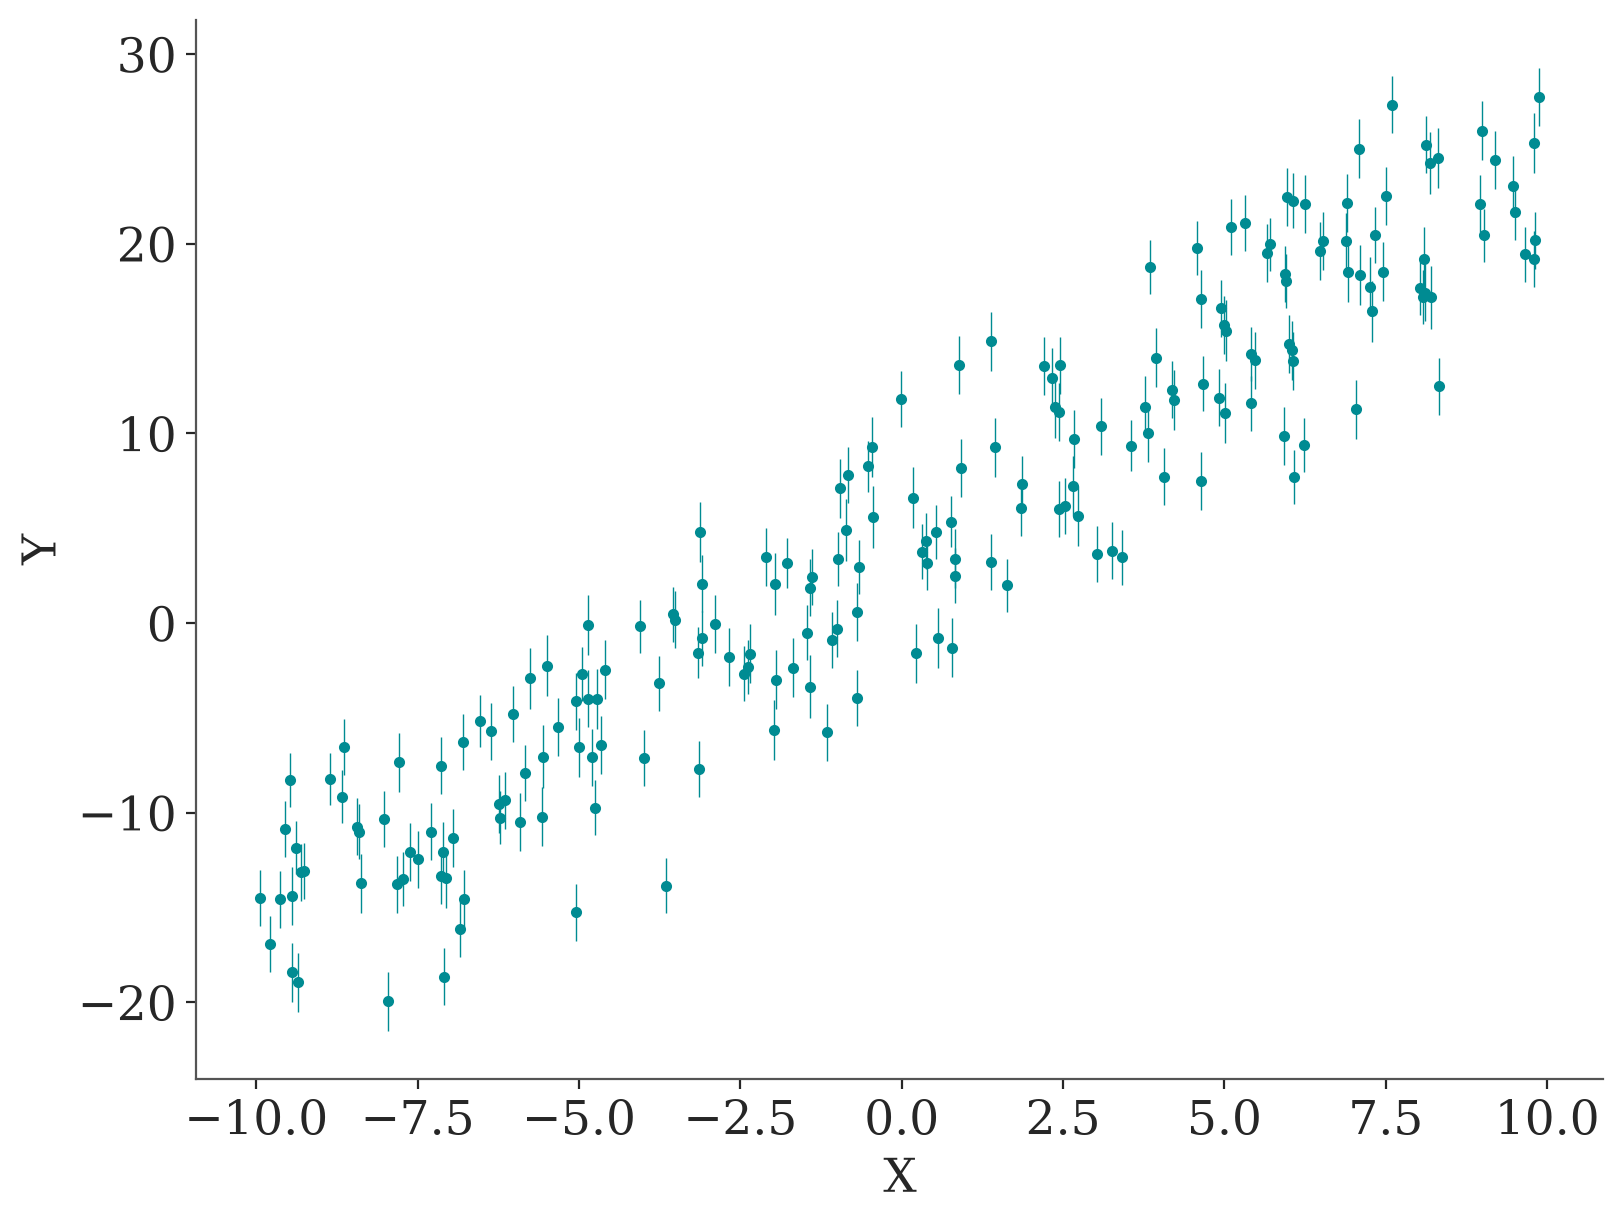

In [4]:
# <your turn>

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1)
# <your turn>

ax.errorbar(x=DATA['x'],
            yerr=DATA['sigma_obs'],
            y=DATA['y_obs'],
            fmt='.', elinewidth=0.5)

# Plot cosmetics
ax.set_xlabel('X')
ax.set_ylabel('Y');

#### Exercise: What do you see as different in this data compared to our last workshop?

## Regression model with intrinsic scatter

Similar to the last example, we assume that our understanding of the physics, hypothetically, suggest that 
$$ Y_{\rm{Model}}(x; m, d) = m x + d $$

and similar to the lecture we assume the following priors on $m$ and $d$:

$$ m \sim \textrm{Uniform}(\min=1,\max=3) $$
$$ d \sim \textrm{Normal}(\mu=3,\sigma=0.2) $$

In the previous tutorial and example, we assumed that $Y_{\rm{obs}} \sim \textrm{Normal}(Y_{\rm{Model}}(x),\sigma_Y)$, where $\hat{y}_{\rm{obs}} = [\hat{y}_1,\cdots,\hat{y}_N]$ as random draws of $Y_{\rm{obs}}$. However, our initial inspection of the data suggests this assumption may not be sufficient in describing the data (uncertainties are underestimated). So we modify our model:

$$ Y_{\rm{obs}} \sim \textrm{Normal}(Y_{\rm{Model}}(x),\sqrt{\sigma_Y^2+ s^2}) $$

where $s$ is a single unknown amount by which our scatter is underestimated by. We make the following assumption:

$$ s \sim \textrm{HalfNormal}(\sigma=5)  $$

(Think about why I suggest a half-normal instead of a normal distributin)

#### Exercise: Build a PyMC model with the variables above and visualise the plate notation.

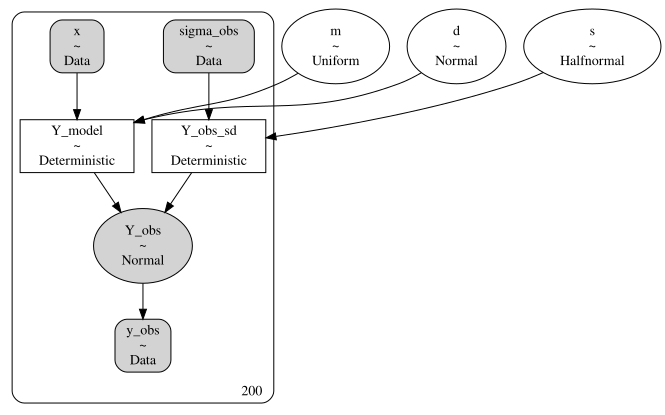

In [5]:
# <your turn>
# just define the model and its components, no sampling or plotting needed here.

with pm.Model() as model1:
    ## First define your data here:
    x = pm.Data('x', DATA['x'])
    y_obs = pm.Data('y_obs', DATA['y_obs'])
    sigma_obs = pm.Data('sigma_obs', DATA['sigma_obs'])

    ## Now define your model variables
    m = pm.Uniform('m', 1, 3)
    d = pm.Normal('d', 3, 0.2)
    s = pm.HalfNormal('s', 5)
    Y_model = pm.Deterministic('Y_model', m*x+d)
    Y_obs_sd = pm.Deterministic('Y_obs_sd',np.sqrt(s**2+sigma_obs**2))
    Y_obs = pm.Normal('Y_obs', mu=Y_model, sigma=Y_obs_sd, observed=y_obs)


pm.model_to_graphviz(model1)

A different way to we can frame our probabilstic models in general is:

$$ \rm{data~model}: [\rm{data}|\rm{process},\rm{parameter}] $$
$$ \rm{process~model}: [\rm{process}|\rm{parameter}] $$
$$ \rm{parameter~model}: [\rm{parameter}] $$

```mermaid
graph TD;
    Parameter-model-->Process-Model;
    Process-Model-->Data-Model;
```

#### Exercise: Think about this framing and what is data model, process model and parameter model here?


### Prior predictive checks

#### Exercise: perform prior predictive sampling with 1000 draws.

In [6]:
# <your turn>
# Perform sampling in this cell (visualise in the following cell)
with model1:
    model1_prior_samp = pm.sample_prior_predictive(draws=1000)

model1_prior_samp

Sampling: [Y_obs, d, m, s]


<xarray.DataTree>
Group: /
├── Group: /prior
│       Dimensions:         (chain: 1, draw: 1000, Y_model_dim_0: 200,
│                            Y_obs_sd_dim_0: 200)
│       Coordinates:
│         * chain           (chain) int64 8B 0
│         * draw            (draw) int64 8kB 0 1 2 3 4 5 6 ... 994 995 996 997 998 999
│         * Y_model_dim_0   (Y_model_dim_0) int64 2kB 0 1 2 3 4 ... 195 196 197 198 199
│         * Y_obs_sd_dim_0  (Y_obs_sd_dim_0) int64 2kB 0 1 2 3 4 ... 195 196 197 198 199
│       Data variables:
│           d               (chain, draw) float64 8kB 3.104 3.129 2.899 ... 2.73 3.019
│           m               (chain, draw) float64 8kB 1.821 2.081 1.358 ... 2.2 2.619
│           Y_model         (chain, draw, Y_model_dim_0) float64 2MB -14.99 ... 28.89
│           Y_obs_sd        (chain, draw, Y_obs_sd_dim_0) float64 2MB 1.654 ... 5.151
│           s               (chain, draw) float64 8kB 0.7425 0.2431 7.57 ... 6.731 4.919
│       Attributes:
│           created_at:                 2026-08-07T00:49:36.179879+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.2.0
│           sample_dims:                ['chain', 'draw']
├── Group: /prior_predictive
│       Dimensions:      (chain: 1, draw: 1000, Y_obs_dim_0: 200)
│       Coordinates:
│         * chain        (chain) int64 8B 0
│         * draw         (draw) int64 8kB 0 1 2 3 4 5 6 ... 993 994 995 996 997 998 999
│         * Y_obs_dim_0  (Y_obs_dim_0) int64 2kB 0 1 2 3 4 5 ... 194 195 196 197 198 199
│       Data variables:
│           Y_obs        (chain, draw, Y_obs_dim_0) float64 2MB -17.72 -12.46 ... 30.61
│       Attributes:
│           created_at:                 2026-08-07T00:49:36.182041+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.2.0
│           sample_dims:                ['chain', 'draw']
├── Group: /observed_data
│       Dimensions:      (Y_obs_dim_0: 200)
│       Coordinates:
│         * Y_obs_dim_0  (Y_obs_dim_0) int64 2kB 0 1 2 3 4 5 ... 194 195 196 197 198 199
│       Data variables:
│           Y_obs        (Y_obs_dim_0) float64 2kB -14.5 -16.93 -14.58 ... 20.18 27.75
│       Attributes:
│           created_at:                 2026-08-07T00:49:36.182891+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.2.0
│           sample_dims:                []
└── Group: /constant_data
        Dimensions:          (x_dim_0: 200, y_obs_dim_0: 200, sigma_obs_dim_0: 200)
        Coordinates:
          * x_dim_0          (x_dim_0) int64 2kB 0 1 2 3 4 5 ... 194 195 196 197 198 199
          * y_obs_dim_0      (y_obs_dim_0) int64 2kB 0 1 2 3 4 5 ... 195 196 197 198 199
          * sigma_obs_dim_0  (sigma_obs_dim_0) int64 2kB 0 1 2 3 4 ... 196 197 198 199
        Data variables:
            x                (x_dim_0) float64 2kB -9.94 -9.793 -9.633 ... 9.809 9.878
            y_obs            (y_obs_dim_0) float64 2kB -14.5 -16.93 ... 20.18 27.75
            sigma_obs        (sigma_obs_dim_0) float64 2kB 1.478 1.48 ... 1.505 1.528
        Attributes:
            created_at:                 2026-08-07T00:49:36.184494+00:00
            creation_library:           ArviZ
            creation_library_version:   1.2.0
            creation_library_language:  Python
            inference_library:          pymc
            inference_library_version:  6.2.0
            sample_dims:                []

#### Exercise: visualise generated prior samples with pair plots for $m$ and $d$.

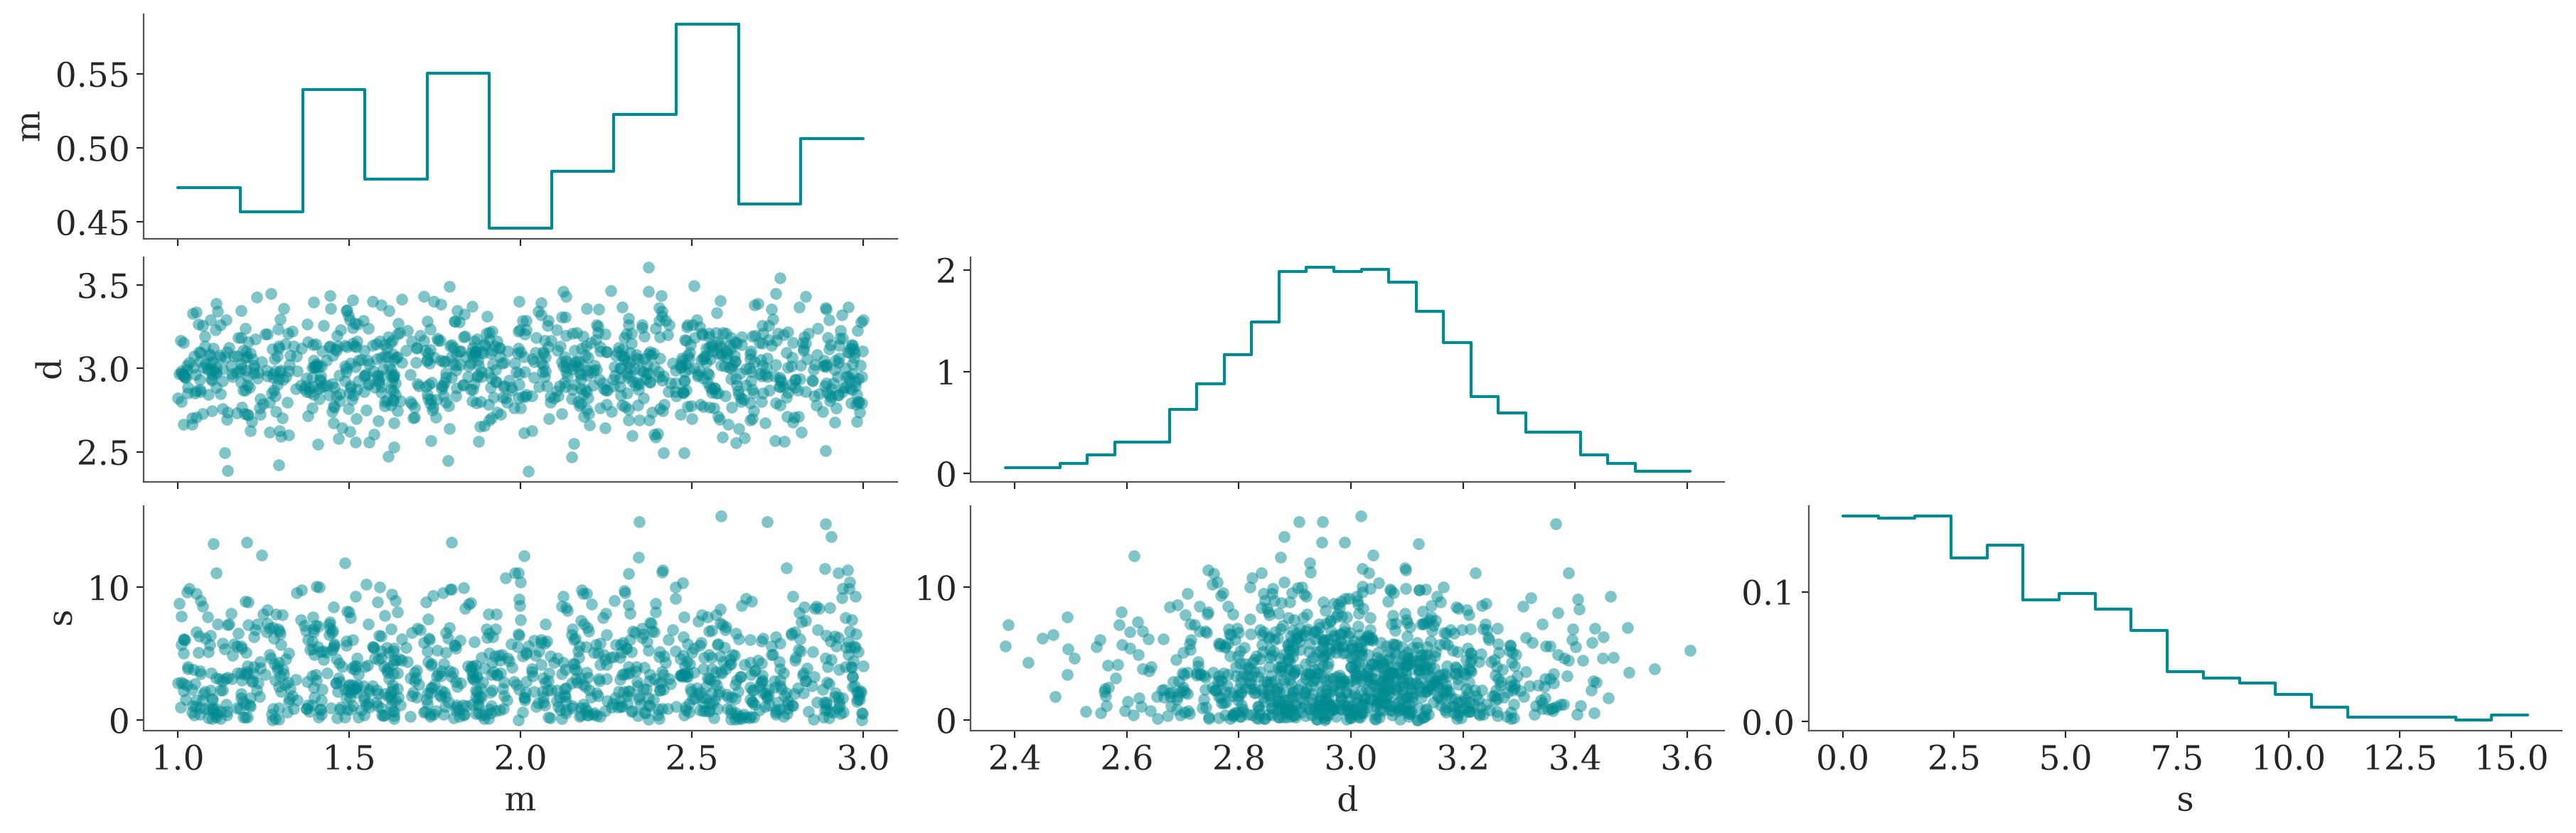

In [7]:
# <your turn>
# Plotting pair-wise (corner) plots

az.plot_pair(model1_prior_samp,
             marginal_kind='hist',
             group='prior',
             var_names=['m','d','s'])

#### Exercise: Visualize prior-predictive samples of $Y_{obs}$ (no HDI plotting needed here).

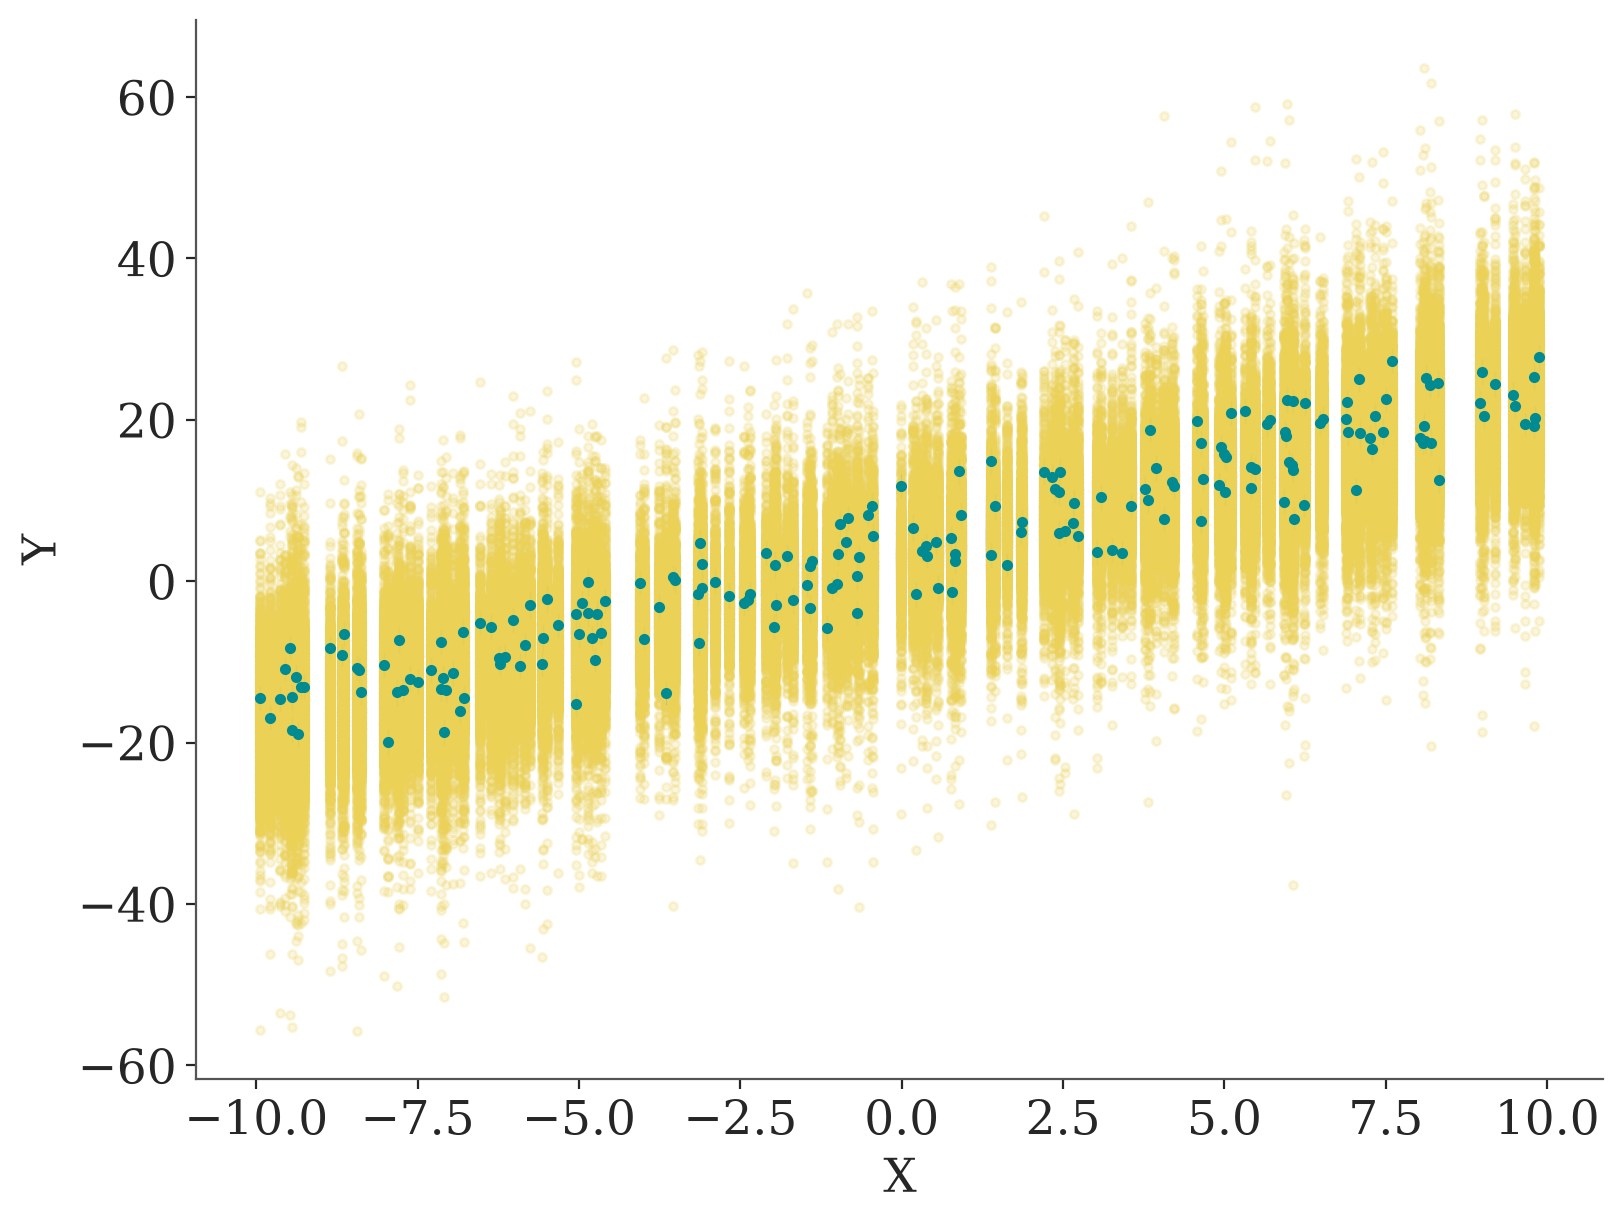

In [8]:
# <your turn>
# Plotting scatter plot

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1)
# <your turn>

ax.errorbar(x=DATA['x'],
            yerr=DATA['sigma_obs'],
            y=DATA['y_obs'],
            fmt='.', elinewidth=0.5,label='Data')

for i in range(1000):
    ax.plot(model1_prior_samp.constant_data['x'],
            model1_prior_samp.prior_predictive['Y_obs'][0,i],
            '.',color=COLORSET[12],alpha=0.2
           )

# Plot cosmetics
ax.set_xlabel('X')
ax.set_ylabel('Y');

### MCMC sampling

#### Exercise: perform MCMC sampling from the posterior, with 4 chains, each with 200 warm-up (tune) draws, 2000 post-warm-up, and keep the warm-up sample.

In [9]:
# <your turn>

with model1:
    model1_inference_samp = pm.sample(tune=200,draws=2000,chains=4,discard_tuned_samples=False)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [m, d, s]


Output()

Sampling 4 chains for 200 tune and 2_000 draw iterations (800 + 8_000 draws total) took 4 seconds.


In [10]:
model1_inference_samp

<xarray.DataTree>
Group: /
├── Group: /warmup_posterior
│       Dimensions:         (chain: 4, draw: 200, Y_model_dim_0: 200,
│                            Y_obs_sd_dim_0: 200)
│       Coordinates:
│         * chain           (chain) int64 32B 0 1 2 3
│         * draw            (draw) int64 2kB 0 1 2 3 4 5 6 ... 194 195 196 197 198 199
│         * Y_model_dim_0   (Y_model_dim_0) int64 2kB 0 1 2 3 4 ... 195 196 197 198 199
│         * Y_obs_sd_dim_0  (Y_obs_sd_dim_0) int64 2kB 0 1 2 3 4 ... 195 196 197 198 199
│       Data variables:
│           d               (chain, draw) float64 6kB 2.334 2.334 2.272 ... 3.278 3.497
│           m               (chain, draw) float64 6kB 1.82 1.82 1.881 ... 2.003 2.012
│           s               (chain, draw) float64 6kB 12.38 12.38 6.9 ... 4.013 3.543
│           Y_model         (chain, draw, Y_model_dim_0) float64 1MB -15.76 ... 23.37
│           Y_obs_sd        (chain, draw, Y_obs_sd_dim_0) float64 1MB 12.47 ... 3.859
│       Attributes:
│           created_at:                 2026-08-07T00:49:43.557450+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.2.0
│           sample_dims:                ['chain', 'draw']
│           sampling_time:              3.9855456352233887
│           tuning_steps:               200
├── Group: /posterior
│       Dimensions:         (chain: 4, draw: 2000, Y_model_dim_0: 200,
│                            Y_obs_sd_dim_0: 200)
│       Coordinates:
│         * chain           (chain) int64 32B 0 1 2 3
│         * draw            (draw) int64 16kB 0 1 2 3 4 5 ... 1995 1996 1997 1998 1999
│         * Y_model_dim_0   (Y_model_dim_0) int64 2kB 0 1 2 3 4 ... 195 196 197 198 199
│         * Y_obs_sd_dim_0  (Y_obs_sd_dim_0) int64 2kB 0 1 2 3 4 ... 195 196 197 198 199
│       Data variables:
│           d               (chain, draw) float64 64kB 3.364 3.405 3.275 ... 3.262 3.475
│           m               (chain, draw) float64 64kB 2.045 1.969 1.977 ... 2.004 2.044
│           s               (chain, draw) float64 64kB 3.795 3.588 3.915 ... 3.577 3.627
│           Y_model         (chain, draw, Y_model_dim_0) float64 13MB -16.97 ... 23.67
│           Y_obs_sd        (chain, draw, Y_obs_sd_dim_0) float64 13MB 4.073 ... 3.935
│       Attributes:
│           created_at:                 2026-08-07T00:49:43.565650+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.2.0
│           sample_dims:                ['chain', 'draw']
│           sampling_time:              3.9855456352233887
│           tuning_steps:               200
├── Group: /warmup_sample_stats
│       Dimensions:                (chain: 4, draw: 200)
│       Coordinates:
│         * chain                  (chain) int64 32B 0 1 2 3
│         * draw                   (draw) int64 2kB 0 1 2 3 4 5 ... 195 196 197 198 199
│       Data variables: (12/18)
│           smallest_eigval        (chain, draw) float64 6kB nan nan nan ... nan nan nan
│           index_in_trajectory    (chain, draw) int64 6kB 0 0 2 2 2 -1 ... -3 0 -2 -6 2
│           step_size              (chain, draw) float64 6kB 0.4436 0.04374 ... 1.46
│           largest_eigval         (chain, draw) float64 6kB nan nan nan ... nan nan nan
│           acceptance_rate        (chain, draw) float64 6kB 6.923e-218 0.0 ... 0.9709
│           tree_depth             (chain, draw) int64 6kB 2 1 2 2 2 2 3 ... 2 2 1 2 3 2
│           ...                     ...
│           perf_counter_start     (chain, draw) float64 6kB 2.451e+05 ... 2.451e+05
│           max_energy_error       (chain, draw) float64 6kB 3.791e+03 ... 0.09121
│           lp                     (chain, draw) float64 6kB -709.9 -709.9 ... -565.4
│

#### Exercise: assess convergence through visualisation of chains. After how many steps do you think convergence seems to be likely?

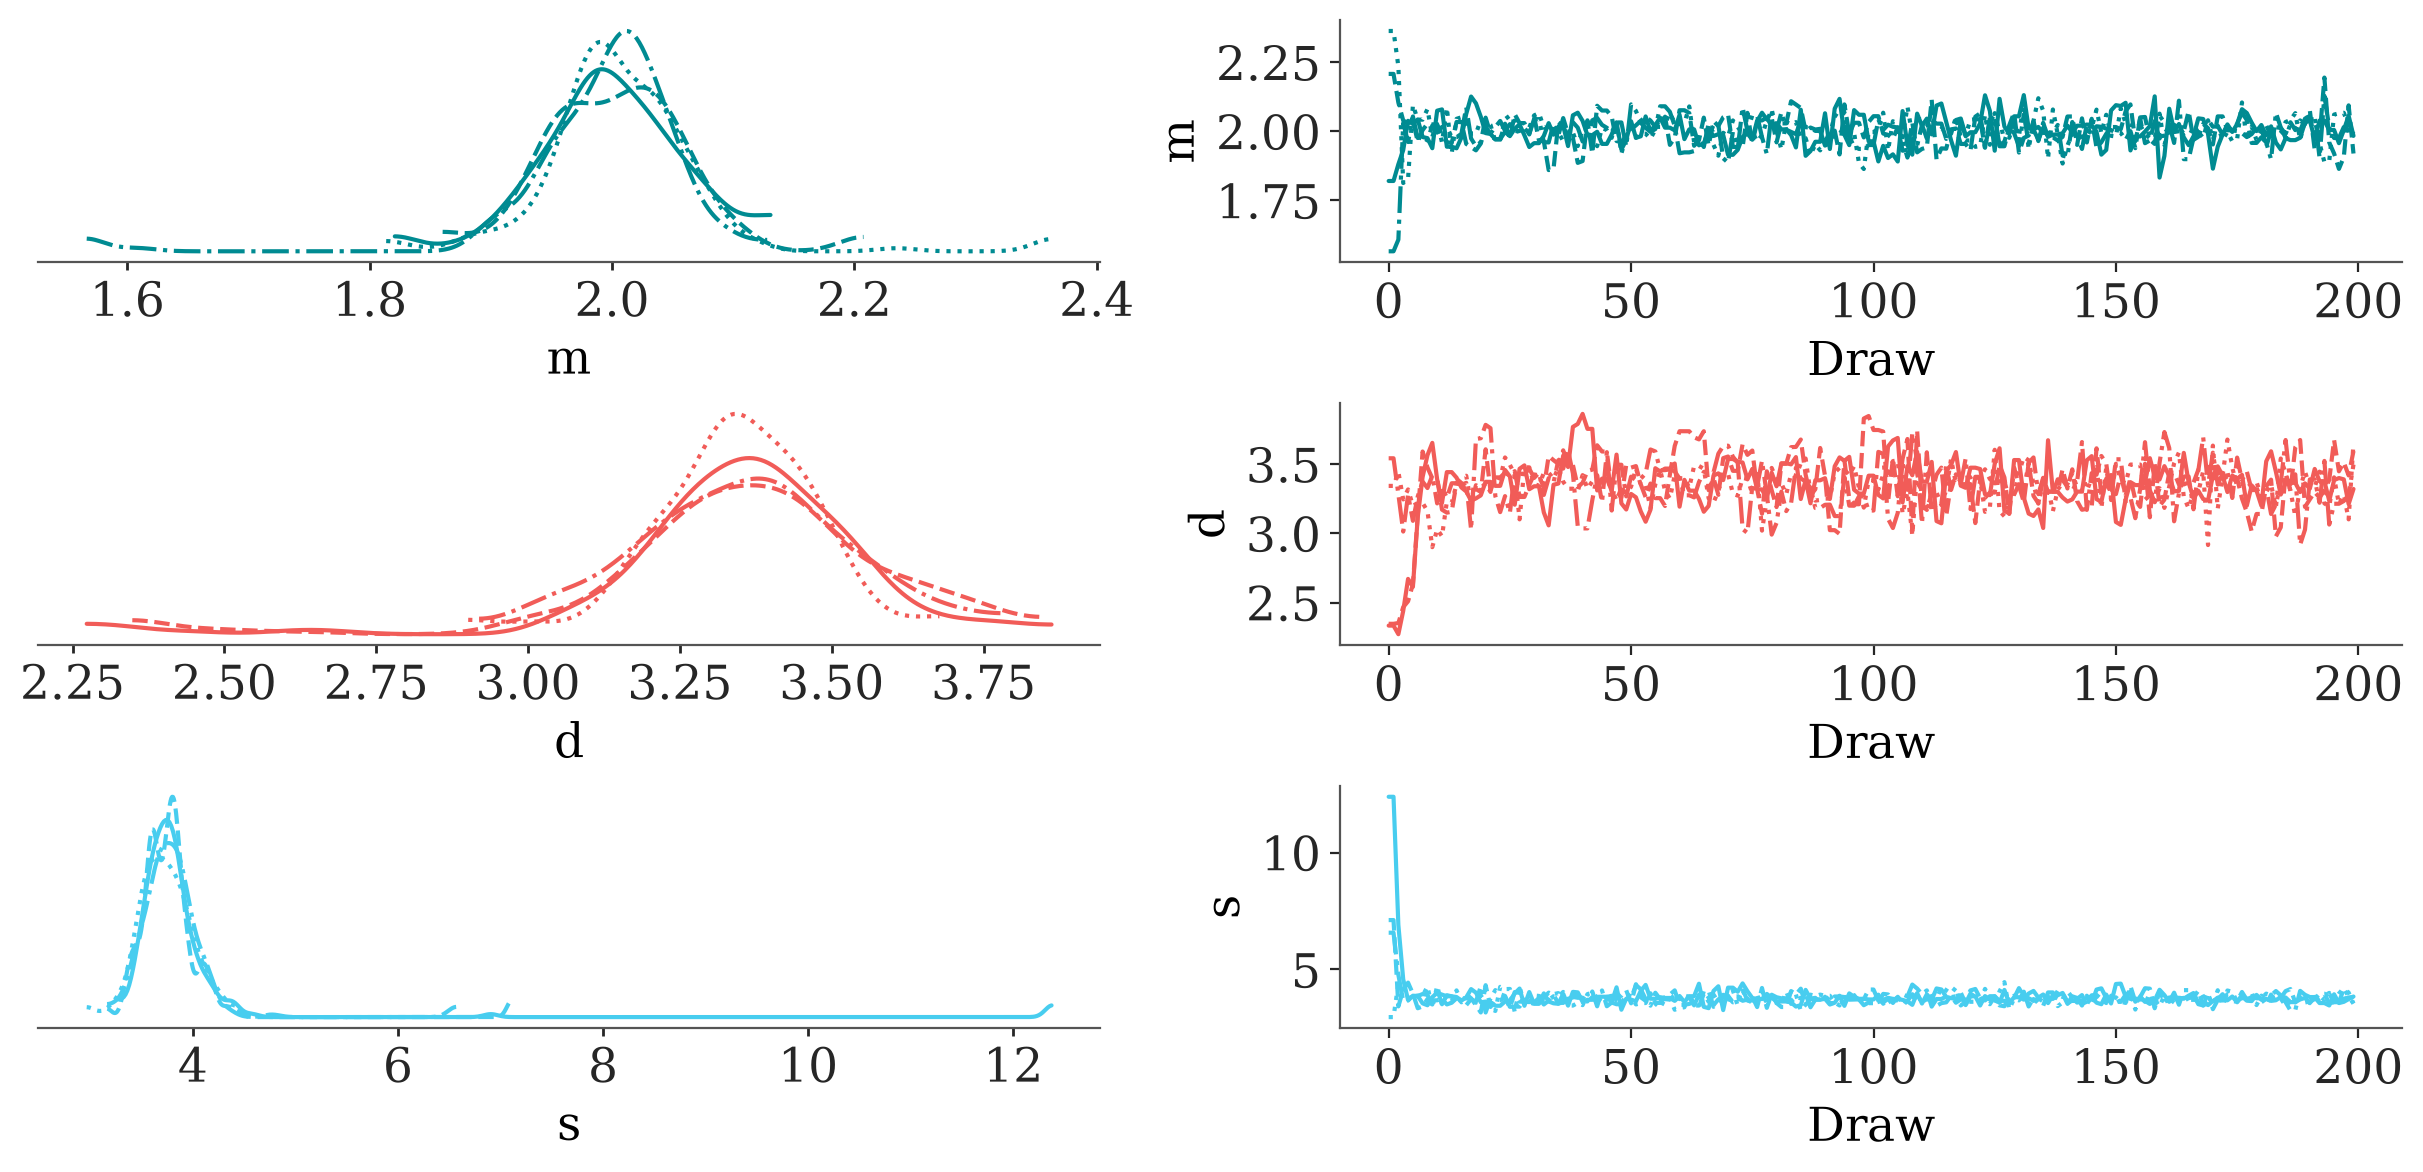

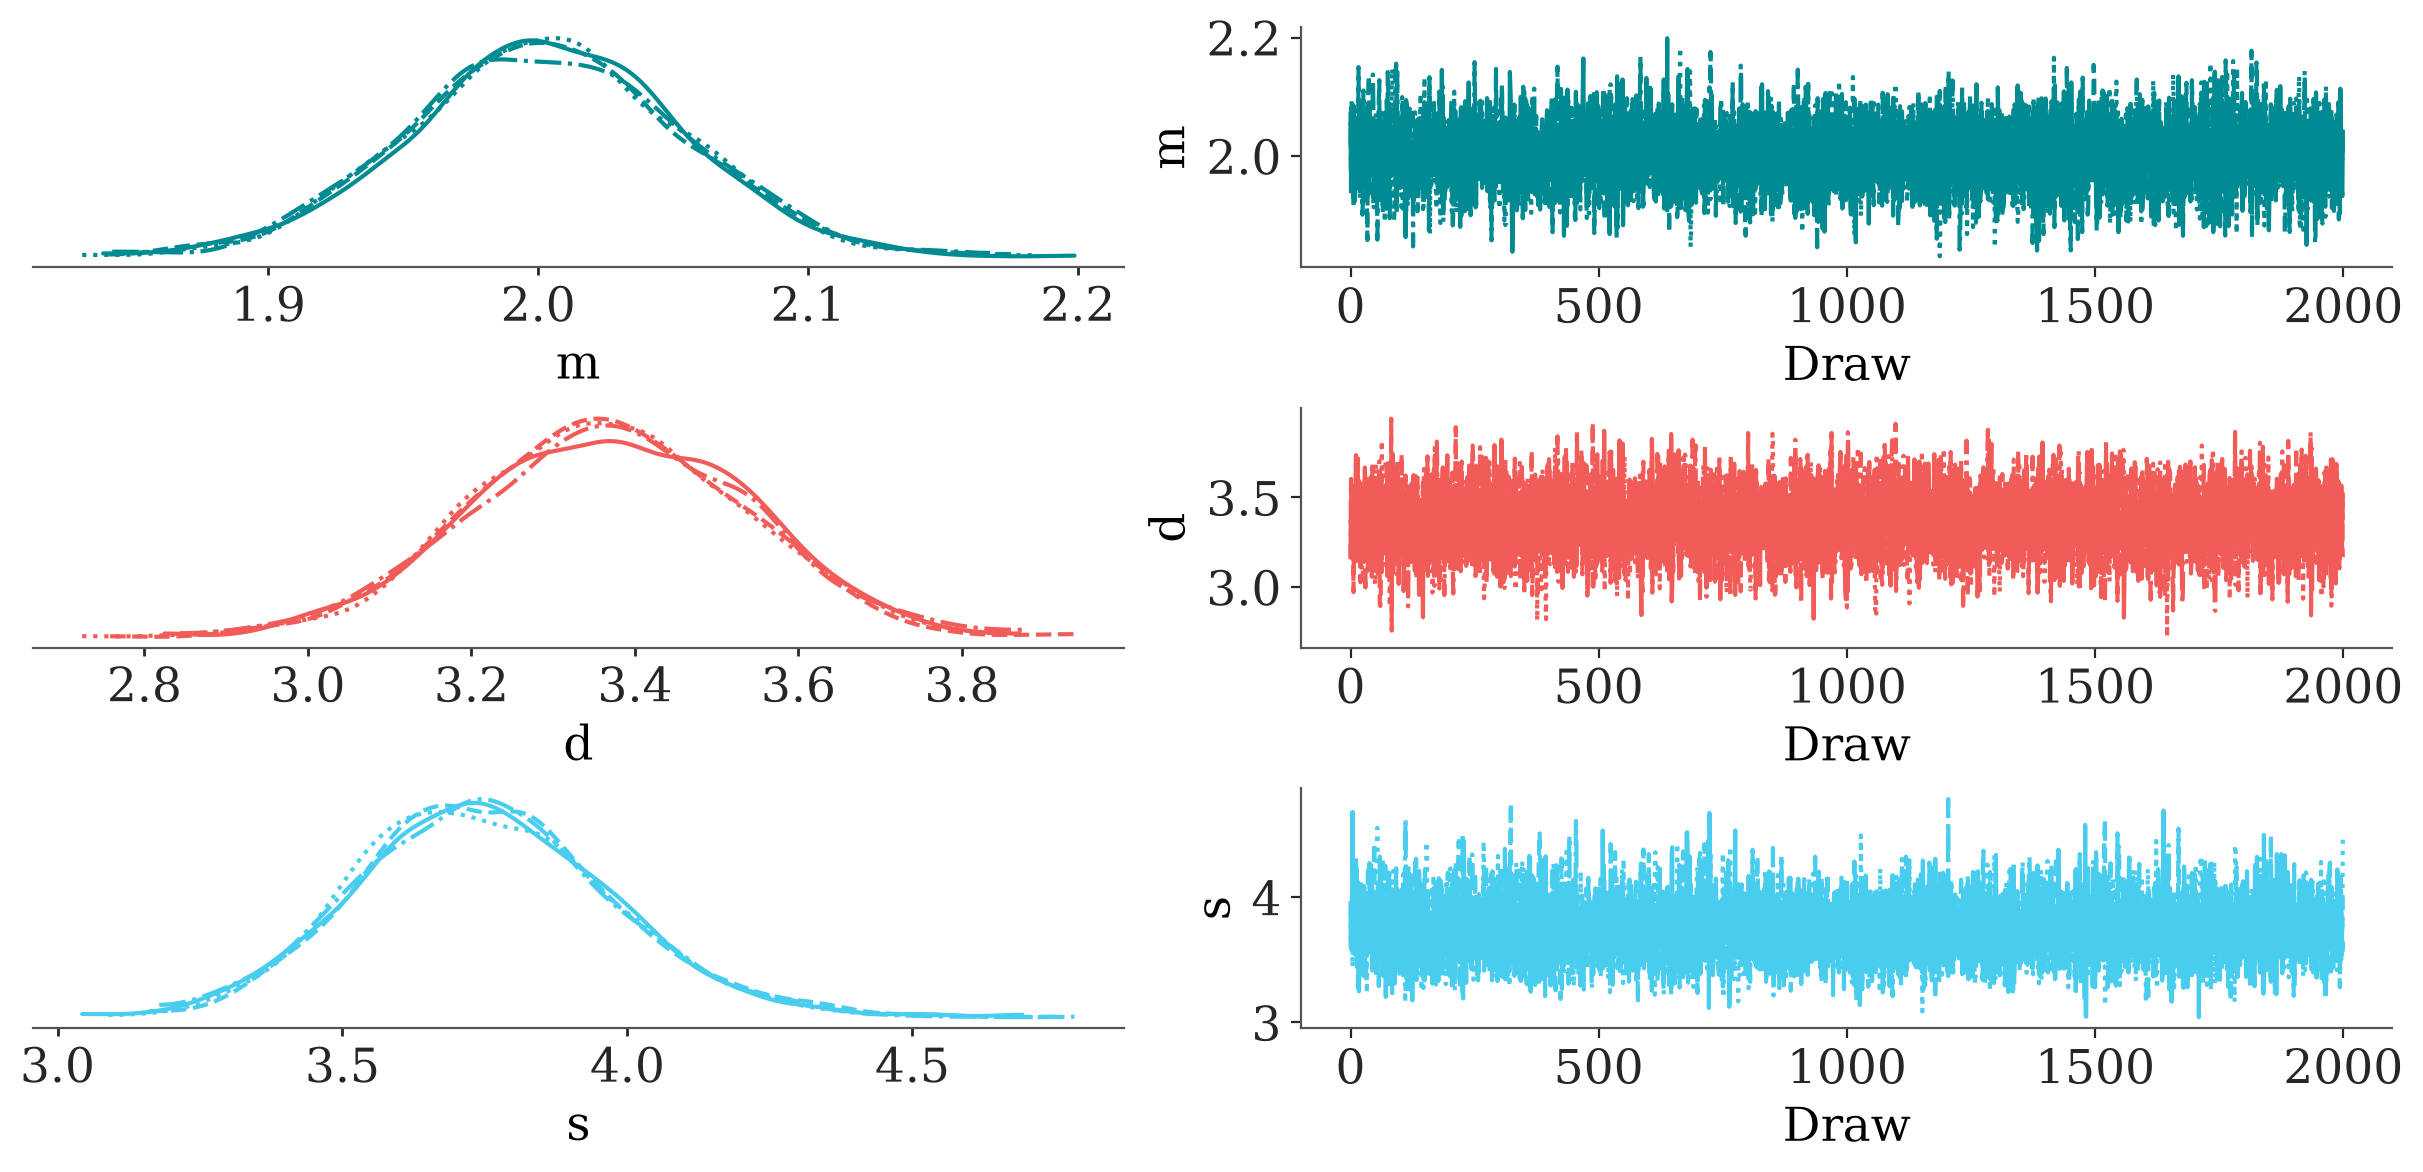

In [11]:
# <your turn>


az.plot_trace_dist(model1_inference_samp,var_names=['m','d','s'],group='warmup_posterior')
az.plot_trace_dist(model1_inference_samp,var_names=['m','d','s'])

#### Exercise: Look at summary statistics of our inference both for the warmup sample and the post-warmup sample, and assess convergence and effective sample size.

In [12]:
# <your turn>
# Use this cell for warmup sample

az.summary(model1_inference_samp,group='warmup_posterior',var_names=['m','d','s'])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
m,2.001,0.06,1.9,2.1,578,403,1.00,0.0028,0.005
d,3.35,0.19,3.1,3.6,352,327,1.02,0.012,0.018
s,3.8,0.5,3.4,4.2,799,492,1.02,0.031,0.19


In [13]:
# <your turn>
# Use this cell for post-warmup sample

az.summary(model1_inference_samp,group='posterior',var_names=['m','d','s'])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
m,2.003,0.0503,1.9,2.1,7023,5902,1.00,0.0006,0.00043
d,3.368,0.167,3.1,3.6,6426,6047,1.00,0.0021,0.0014
s,3.751,0.225,3.4,4.1,7050,5953,1.00,0.0027,0.0021


#### Exercise: redo the last step, but print out median and 95% HDI intervals.

### Influence of priors

#### Exercise: Plot prior and posterior samples of $m,d,s$ and think about if there is any evidence for priors influencing the posterior strongly.

In [14]:
# Run this cell just to combine the prior predictive sample Xarray with the posterior sample Xarray
model1_inference_samp.update(model1_prior_samp)

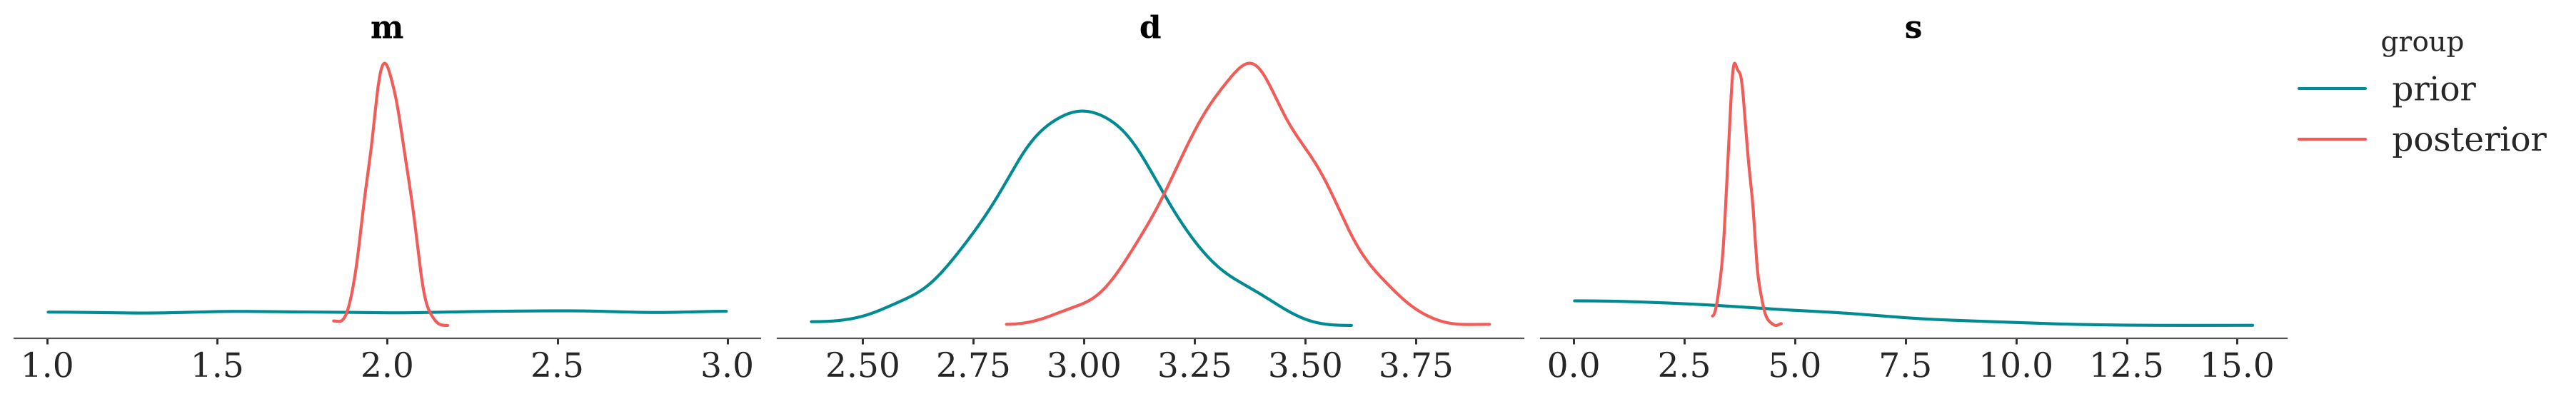

In [15]:
# <your turn>

az.plot_prior_posterior(model1_inference_samp,var_names=['m','d','s'])

### Posterior predictive sampling

#### Exercise: Perform posterior predictive sampling (make sure to use `extend_inferencedata` so it generates a group in the existing data tree).

In [16]:
# <your turn>

with model1:
    pm.sample_posterior_predictive(model1_inference_samp, extend_inferencedata=True)

Sampling: [Y_obs]


Output()

In [17]:
model1_inference_samp

<xarray.DataTree>
Group: /
├── Group: /warmup_posterior
│       Dimensions:         (chain: 4, draw: 200, Y_model_dim_0: 200,
│                            Y_obs_sd_dim_0: 200)
│       Coordinates:
│         * chain           (chain) int64 32B 0 1 2 3
│         * draw            (draw) int64 2kB 0 1 2 3 4 5 6 ... 194 195 196 197 198 199
│         * Y_model_dim_0   (Y_model_dim_0) int64 2kB 0 1 2 3 4 ... 195 196 197 198 199
│         * Y_obs_sd_dim_0  (Y_obs_sd_dim_0) int64 2kB 0 1 2 3 4 ... 195 196 197 198 199
│       Data variables:
│           d               (chain, draw) float64 6kB 2.334 2.334 2.272 ... 3.278 3.497
│           m               (chain, draw) float64 6kB 1.82 1.82 1.881 ... 2.003 2.012
│           s               (chain, draw) float64 6kB 12.38 12.38 6.9 ... 4.013 3.543
│           Y_model         (chain, draw, Y_model_dim_0) float64 1MB -15.76 ... 23.37
│           Y_obs_sd        (chain, draw, Y_obs_sd_dim_0) float64 1MB 12.47 ... 3.859
│       Attributes:
│           created_at:                 2026-08-07T00:49:43.557450+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.2.0
│           sample_dims:                ['chain', 'draw']
│           sampling_time:              3.9855456352233887
│           tuning_steps:               200
├── Group: /posterior
│       Dimensions:         (chain: 4, draw: 2000, Y_model_dim_0: 200,
│                            Y_obs_sd_dim_0: 200)
│       Coordinates:
│         * chain           (chain) int64 32B 0 1 2 3
│         * draw            (draw) int64 16kB 0 1 2 3 4 5 ... 1995 1996 1997 1998 1999
│         * Y_model_dim_0   (Y_model_dim_0) int64 2kB 0 1 2 3 4 ... 195 196 197 198 199
│         * Y_obs_sd_dim_0  (Y_obs_sd_dim_0) int64 2kB 0 1 2 3 4 ... 195 196 197 198 199
│       Data variables:
│           d               (chain, draw) float64 64kB 3.364 3.405 3.275 ... 3.262 3.475
│           m               (chain, draw) float64 64kB 2.045 1.969 1.977 ... 2.004 2.044
│           s               (chain, draw) float64 64kB 3.795 3.588 3.915 ... 3.577 3.627
│           Y_model         (chain, draw, Y_model_dim_0) float64 13MB -16.97 ... 23.67
│           Y_obs_sd        (chain, draw, Y_obs_sd_dim_0) float64 13MB 4.073 ... 3.935
│       Attributes:
│           created_at:                 2026-08-07T00:49:43.565650+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.2.0
│           sample_dims:                ['chain', 'draw']
│           sampling_time:              3.9855456352233887
│           tuning_steps:               200
├── Group: /warmup_sample_stats
│       Dimensions:                (chain: 4, draw: 200)
│       Coordinates:
│         * chain                  (chain) int64 32B 0 1 2 3
│         * draw                   (draw) int64 2kB 0 1 2 3 4 5 ... 195 196 197 198 199
│       Data variables: (12/18)
│           smallest_eigval        (chain, draw) float64 6kB nan nan nan ... nan nan nan
│           index_in_trajectory    (chain, draw) int64 6kB 0 0 2 2 2 -1 ... -3 0 -2 -6 2
│           step_size              (chain, draw) float64 6kB 0.4436 0.04374 ... 1.46
│           largest_eigval         (chain, draw) float64 6kB nan nan nan ... nan nan nan
│           acceptance_rate        (chain, draw) float64 6kB 6.923e-218 0.0 ... 0.9709
│           tree_depth             (chain, draw) int64 6kB 2 1 2 2 2 2 3 ... 2 2 1 2 3 2
│           ...                     ...
│           perf_counter_start     (chain, draw) float64 6kB 2.451e+05 ... 2.451e+05
│           max_energy_error       (chain, draw) float64 6kB 3.791e+03 ... 0.09121
│           lp                     (chain, draw) float64 6kB -709.9 -709.9 ... -565.4
│

#### Exercise: make a scatter plot of the posterior predictive of $Y_{model}$ and $Y_{obs}$ on top of data.

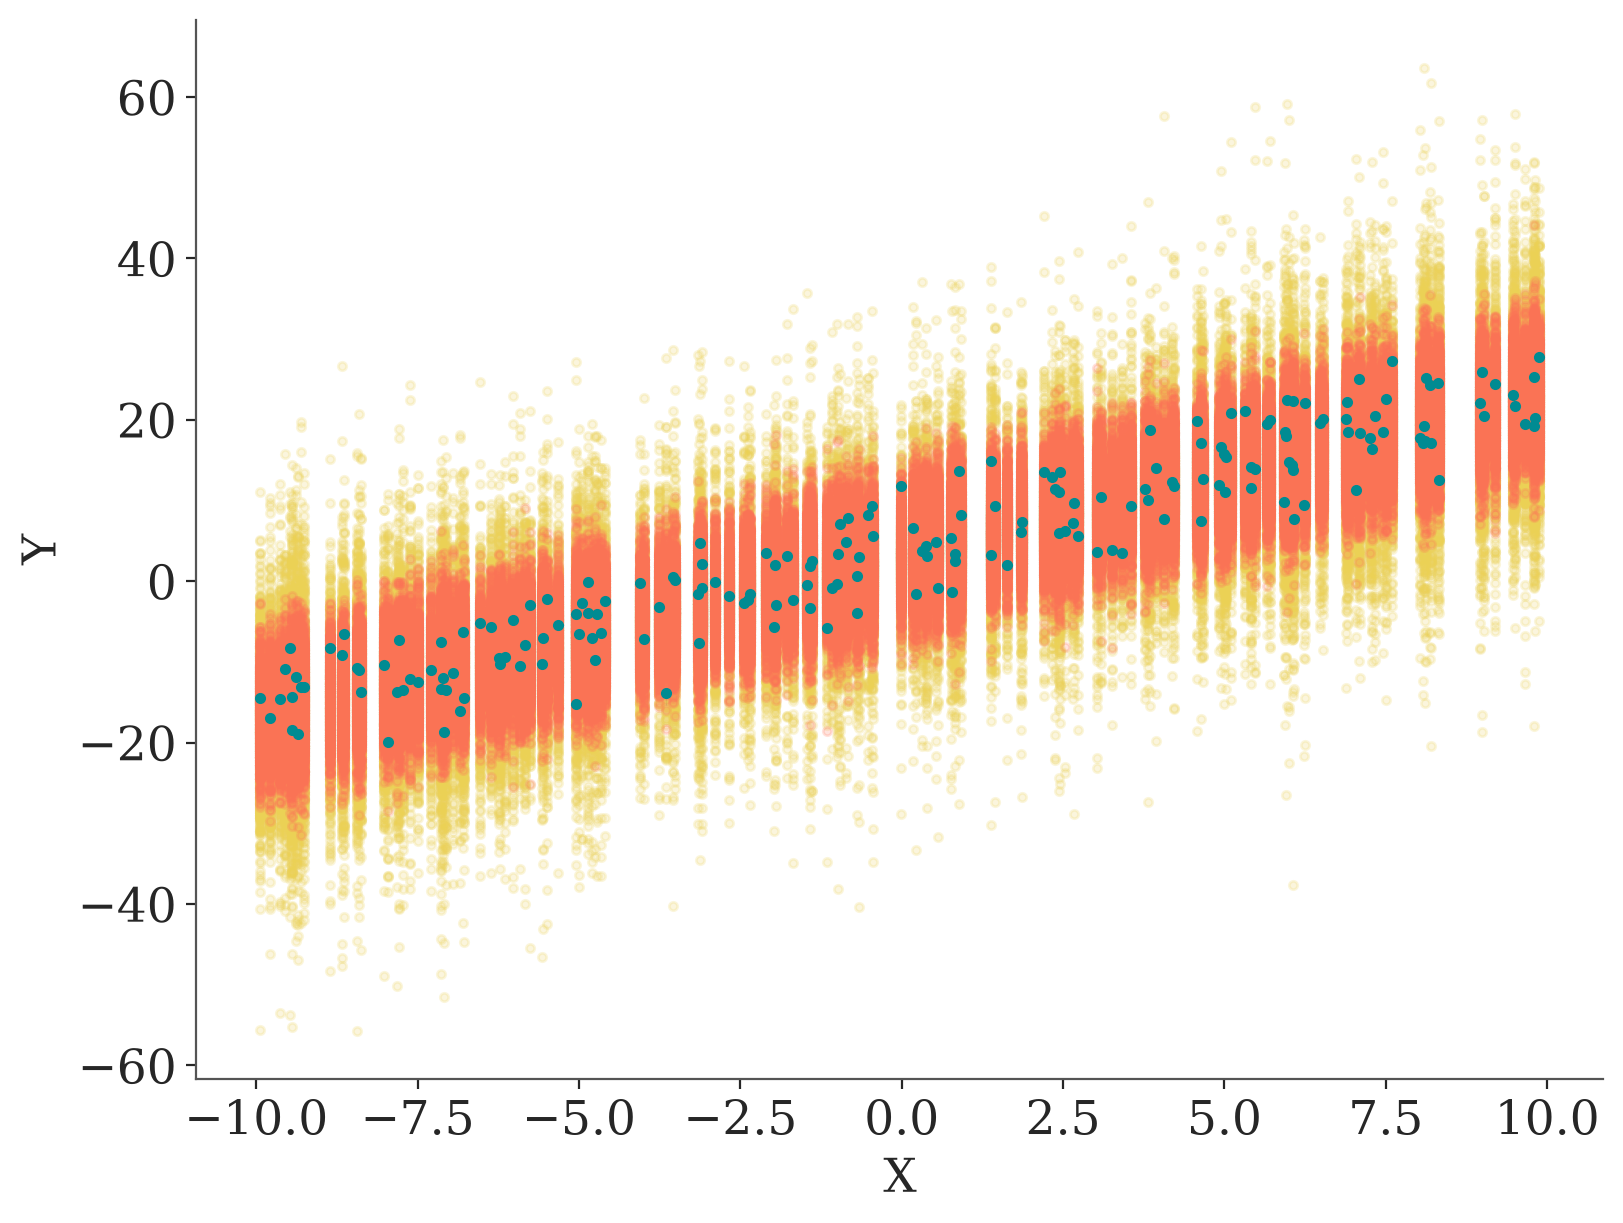

In [21]:
# <your turn>
# Plotting scatter plot

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1)
# <your turn>

ax.errorbar(x=DATA['x'],
            yerr=DATA['sigma_obs'],
            y=DATA['y_obs'],
            fmt='.', elinewidth=0.5,label='Data')

for i in range(1000):
    ax.plot(model1_inference_samp.constant_data['x'],
            model1_inference_samp.prior_predictive['Y_obs'][0,i],
            '.',color=COLORSET[12],alpha=0.2
           )


for i in range(1000):
    ax.plot(model1_inference_samp.constant_data['x'],
            model1_inference_samp.posterior_predictive['Y_obs'][0,i],
            '.',color=COLORSET[10],alpha=0.2
           )

# Plot cosmetics
ax.set_xlabel('X')
ax.set_ylabel('Y');

#### Exercise: use the HDI method from previous tutorial to make shaded interval regions and visualize 95% HDI.

In [19]:
Y_model_ppc_hdi95 = az.hdi(model1_inference_samp, group='posterior',prob=0.95, var_names='Y_model')
Y_obs_ppc_hdi95 = az.hdi(model1_inference_samp, group='posterior_predictive',prob=0.95, var_names='Y_obs')

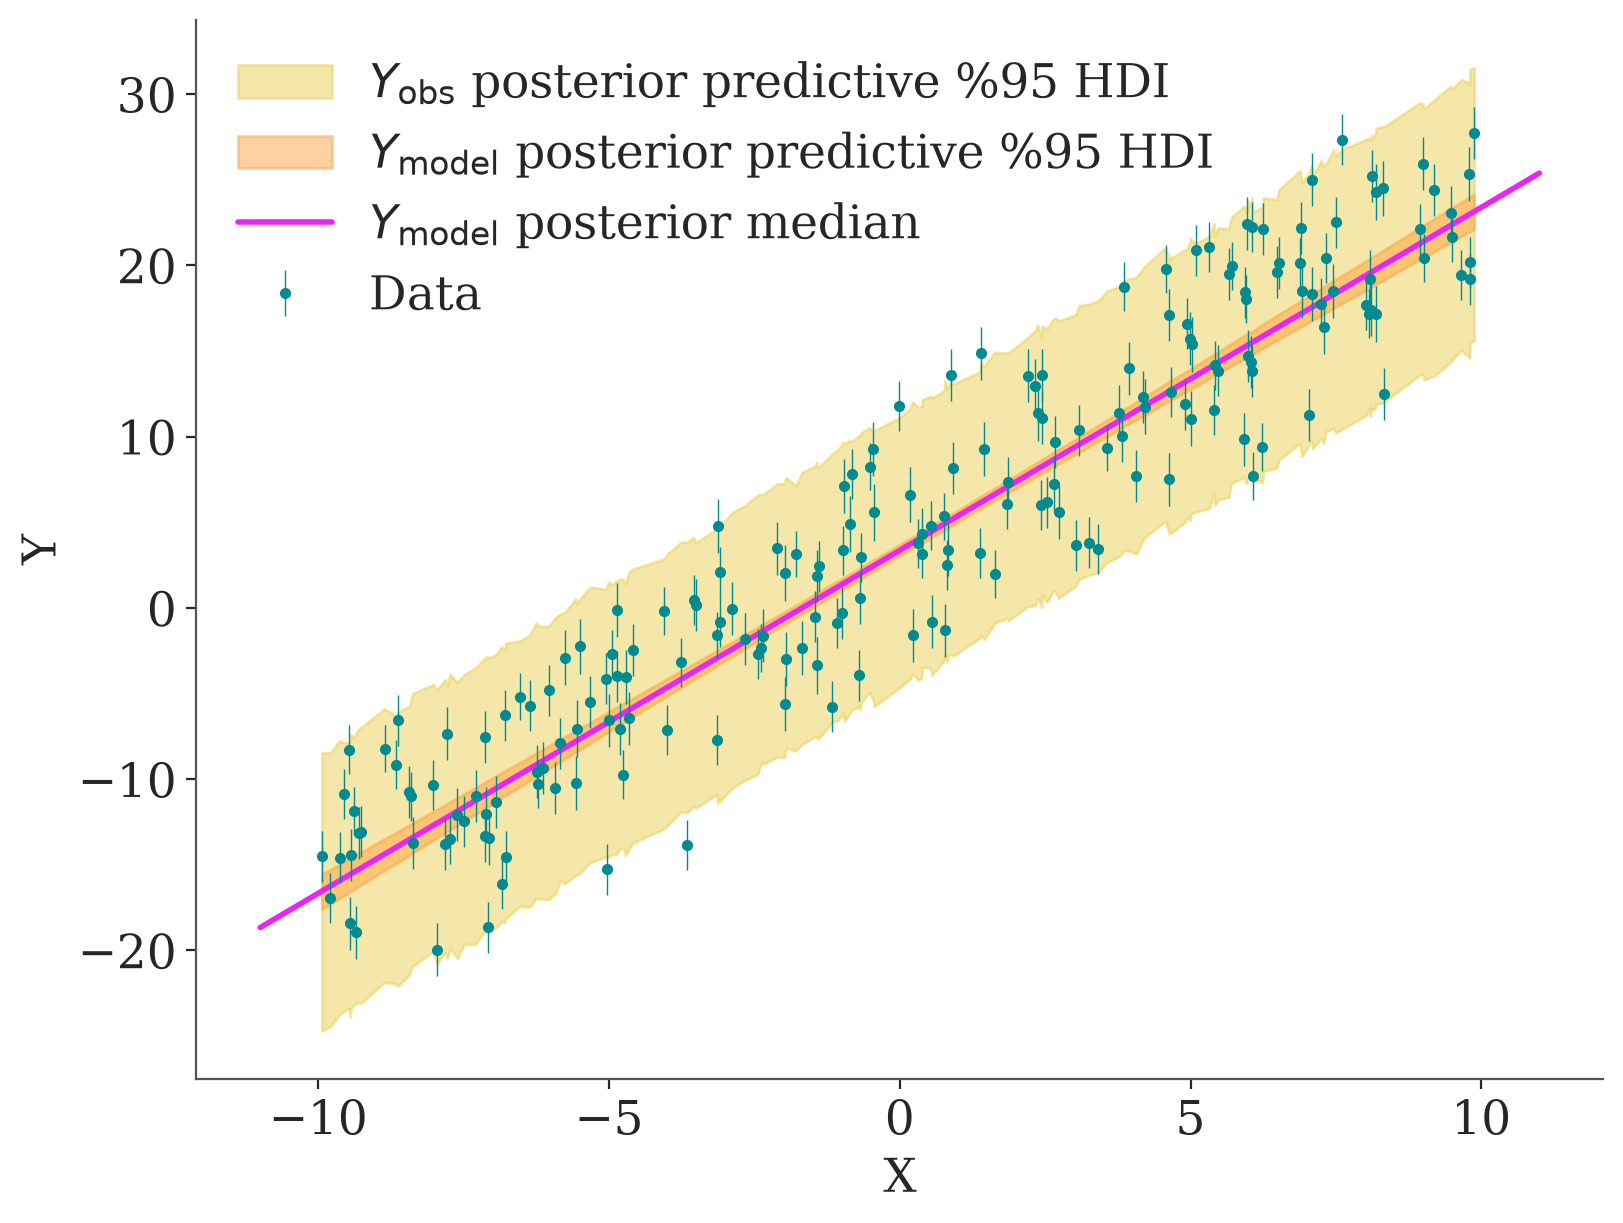

In [22]:
# <your turn>
mean_m = model1_inference_samp.posterior['m'].median().values
mean_d = model1_inference_samp.posterior['d'].median().values
test_x = np.linspace(-11,11)
test_y = mean_m* test_x + mean_d

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1)
# <your turn>

ax.fill_between(model1_inference_samp.constant_data['x'],
                Y_obs_ppc_hdi95['Y_obs'].sel({'ci_bound':'lower'}),
                Y_obs_ppc_hdi95['Y_obs'].sel({'ci_bound':'upper'}),
                color=COLORSET[12], alpha=0.5,
                label=r'$Y_{\rm{obs}}$ posterior predictive %95 HDI'
               )


ax.fill_between(model1_inference_samp.constant_data['x'],
                Y_model_ppc_hdi95['Y_model'].sel({'ci_bound':'lower'}),
                Y_model_ppc_hdi95['Y_model'].sel({'ci_bound':'upper'}),
                color=COLORSET[11], alpha=0.5,
                label=r'$Y_{\rm{model}}$ posterior predictive %95 HDI'
               )

ax.plot(test_x, test_y, color=COLORSET[7],label=r'$Y_{\rm{model}}$ posterior median',lw=2)



ax.errorbar(x=DATA['x'],
            yerr=DATA['sigma_obs'],
            y=DATA['y_obs'],
            fmt='.', elinewidth=0.5,label='Data')

ax.legend(loc=2)

# Plot cosmetics
ax.set_xlabel('X')
ax.set_ylabel('Y');

## You can now save the notebook and download it.